<a href="https://colab.research.google.com/github/dharshinikumaravel2004-byte/ecg-classification-alexnet/blob/main/Label_Smoothing_Crossentropy_alexnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from keras.models import Model
from keras.layers import Input
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/mit dataset/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/mit dataset/mitbih_test.csv"

In [ ]:
train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


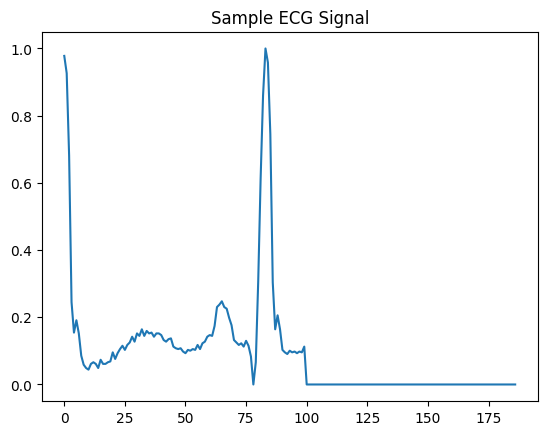

In [ ]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

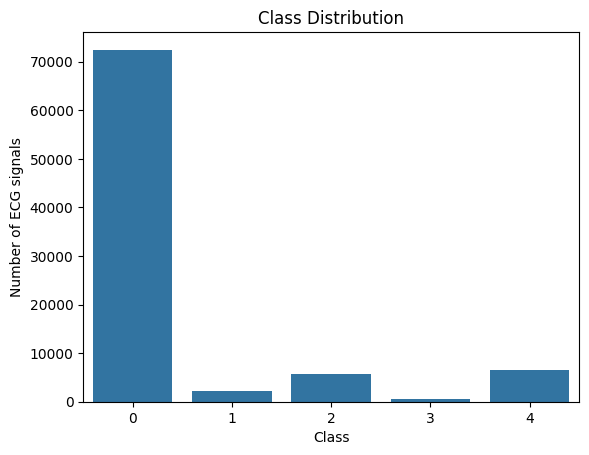

In [ ]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

In [ ]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [ ]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [ ]:
print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [ ]:
X_res = X_res[:120000]
y_res = y_res[:120000]

In [ ]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [ ]:
X_train = np.array(X_train).reshape(-1,187,1)
X_val   = np.array(X_val).reshape(-1,187,1)
X_test  = np.array(X_test).reshape(-1,187,1)

In [ ]:
def alexnet_ecg():

    inputs = Input(shape=(187, 1))

    x = Conv1D(96, kernel_size=11, strides=4, activation='relu')(inputs)
    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Conv1D(256, kernel_size=5, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Conv1D(384, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(384, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)

    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Flatten()(x)

    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    loss_fn = tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    )

    model.compile(
        optimizer='adam',
        loss=loss_fn,
        metrics=['accuracy']
    )

    return model

In [ ]:
model = alexnet_ecg()
print("Loss:", model.loss)

Loss: <LossFunctionWrapper(<function categorical_crossentropy at 0x799f1f42fc40>, kwargs={'from_logits': False, 'label_smoothing': 0.1, 'axis': -1})>


In [ ]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_accuracies = []

X_res = np.array(X_res).reshape(-1,187,1)
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr = to_categorical(y_res[train_idx], 5)
    y_va = to_categorical(y_res[val_idx], 5)

    model = alexnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=10,
        batch_size=128,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    cv_accuracies.append(acc)
print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8815 - loss: 0.6528
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9590 - loss: 0.4910
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9709 - loss: 0.4630
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9779 - loss: 0.4479
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9818 - loss: 0.4394
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9836 - loss: 0.4338
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9865 - loss: 0.4274
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9875 - loss: 0.4257
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9888 - loss: 0.4219
Epoch 10/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9887 - loss: 0.4225
Fold 1 Accuracy: 0.9839

Fold 2
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8683 - loss: 0.6712
Epoch 2/10


In [ ]:
model = alexnet_ecg()
print(model.loss)

<LossFunctionWrapper(<function categorical_crossentropy at 0x799f1f42fc40>, kwargs={'from_logits': False, 'label_smoothing': 0.1, 'axis': -1})>


In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.8846 - loss: 0.6472 - val_accuracy: 0.9507 - val_loss: 0.5049
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9614 - loss: 0.4869 - val_accuracy: 0.9707 - val_loss: 0.4530
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9722 - loss: 0.4617 - val_accuracy: 0.9704 - val_loss: 0.4542
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9785 - loss: 0.4462 - val_accuracy: 0.9790 - val_loss: 0.4359
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9820 - loss: 0.4378 - val_accuracy: 0.9789 - val_loss: 0.4355
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9844 - loss: 0.4317 - val_accuracy: 0.9840 - val_loss: 0.4255
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9859 - loss: 0.4278 - val_accuracy: 0.9840 - val_loss: 0.4275
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9869 - loss: 0.4253 - val_accuracy:

In [ ]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = np.argmax(y_val, axis=1)

mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", mcc)

750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Validation MCC: 0.976088396026452


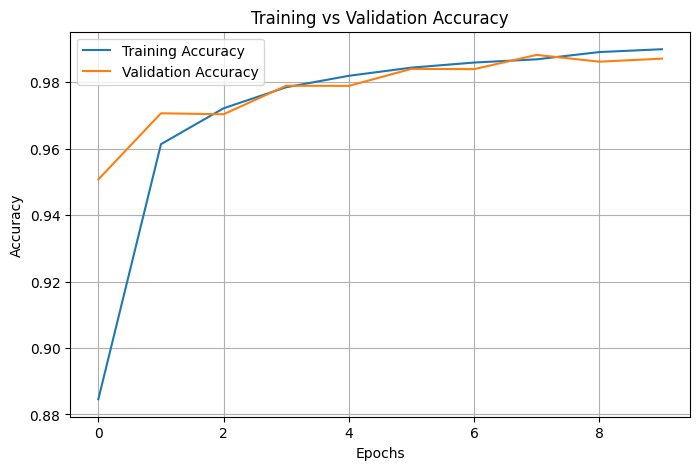

Final Training Accuracy: 0.9900
Final Validation Accuracy: 0.9871


In [ ]:
# Cell 24: Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

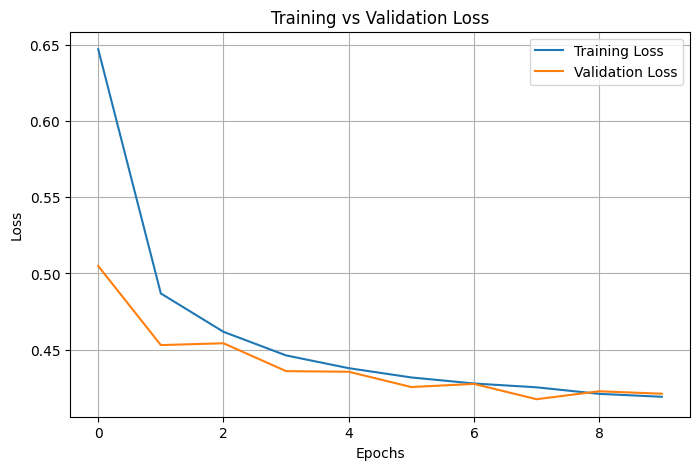

Final Training Loss: 0.4191
Final Validation Loss: 0.4211


In [ ]:
# Cell 25: Loss Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4393
Test Accuracy: 0.9792


In [ ]:
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     18118
         1.0       0.71      0.86      0.78       556
         2.0       0.96      0.95      0.95      1448
         3.0       0.89      0.65      0.75       162
         4.0       0.99      0.98      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.91      0.88      0.89     21892
weighted avg       0.98      0.98      0.98     21892



In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# Predictions
y_test_pred = np.argmax(model.predict(X_test), axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
num_classes = cm.shape[0]

# Lists
precision = []
recall = []
f1 = []
specificity = []
support = []

for i in range(num_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    prec = TP / (TP + FP) if (TP + FP) != 0 else 0
    rec  = TP / (TP + FN) if (TP + FN) != 0 else 0
    spec = TN / (TN + FP) if (TN + FP) != 0 else 0
    f1_score = (2 * prec * rec) / (prec + rec) if (prec + rec) != 0 else 0

    precision.append(prec)
    recall.append(rec)
    f1.append(f1_score)
    specificity.append(spec)
    support.append(np.sum(cm[i, :]))

# Convert to numpy
precision = np.array(precision)
recall = np.array(recall)
f1 = np.array(f1)
specificity = np.array(specificity)
support = np.array(support)

# Accuracy
accuracy = np.trace(cm) / np.sum(cm)

# Macro Average
macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1)
macro_spec = np.mean(specificity)

# Weighted Average
weights = support / np.sum(support)

weighted_precision = np.sum(precision * weights)
weighted_recall = np.sum(recall * weights)
weighted_f1 = np.sum(f1 * weights)
weighted_spec = np.sum(specificity * weights)

# Create DataFrame
report_df = pd.DataFrame({
    "precision": precision,
    "recall": recall,
    "f1-score": f1,
    "specificity": specificity,
    "support": support
})

report_df.index = [f"Class {i}" for i in range(num_classes)]

# Add summary rows
summary_df = pd.DataFrame({
    "precision": [accuracy, macro_precision, weighted_precision],
    "recall":    [accuracy, macro_recall, weighted_recall],
    "f1-score":  [accuracy, macro_f1, weighted_f1],
    "specificity": [np.nan, macro_spec, weighted_spec],
    "support":   [np.sum(support), np.sum(support), np.sum(support)]
}, index=["accuracy", "macro avg", "weighted avg"])

# Combine
final_df = pd.concat([report_df, summary_df])

# Print
print(final_df.round(3))

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision  recall  f1-score  specificity  support
Class 0           0.990   0.988     0.989        0.953    18118
Class 1           0.710   0.856     0.777        0.991      556
Class 2           0.957   0.945     0.951        0.997     1448
Class 3           0.890   0.648     0.750        0.999      162
Class 4           0.993   0.984     0.989        0.999     1608
accuracy          0.979   0.979     0.979          NaN    21892
macro avg         0.908   0.884     0.891        0.988    21892
weighted avg      0.980   0.979     0.979        0.961    21892


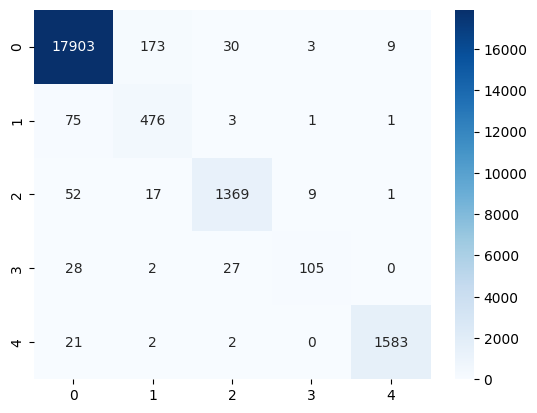

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()